In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/glassdoor_reviews.csv")

df['firm'].value_counts()

In [ ]:
corr = df[[
    'overall_rating',
    'work_life_balance',
    'culture_values',
    'career_opp',
    'comp_benefits',
    'senior_mgmt'
]].corr()

print(corr['overall_rating'].sort_values(ascending=False))

overall_rating       1.000000
culture_values       0.766156
senior_mgmt          0.751829
career_opp           0.715081
comp_benefits        0.609950
work_life_balance    0.563333
Name: overall_rating, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

df_model = df[[
    'work_life_balance',
    'culture_values',
    'career_opp',
    'comp_benefits',
    'senior_mgmt',
    'recommend'
]].dropna()

X = df_model[[
    'work_life_balance',
    'culture_values',
    'career_opp',
    'comp_benefits',
    'senior_mgmt'
]]

y = (df_model['recommend'] == 'v').astype(int)

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_

In [ ]:
features = X.columns

for f, imp in zip(features, importances):
    print(f"{f}: {imp:.3f}")

work_life_balance: 0.040
culture_values: 0.388
career_opp: 0.189
comp_benefits: 0.069
senior_mgmt: 0.314


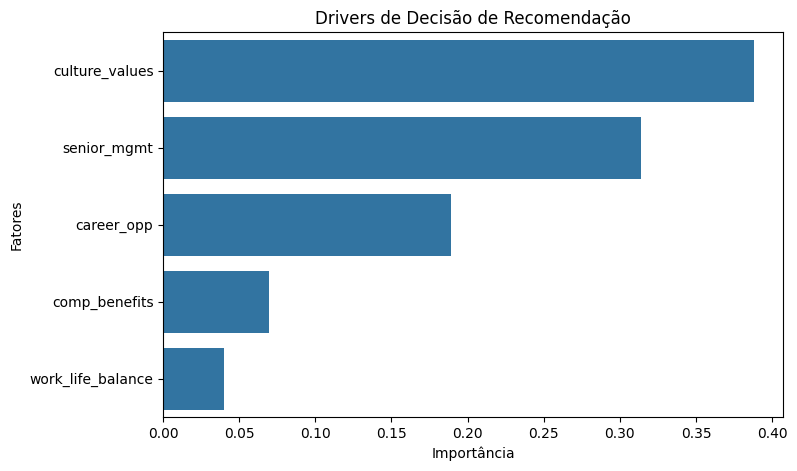

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = X.columns
importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Drivers de Decisão de Recomendação')
plt.xlabel('Importância')
plt.ylabel('Fatores')
plt.show()

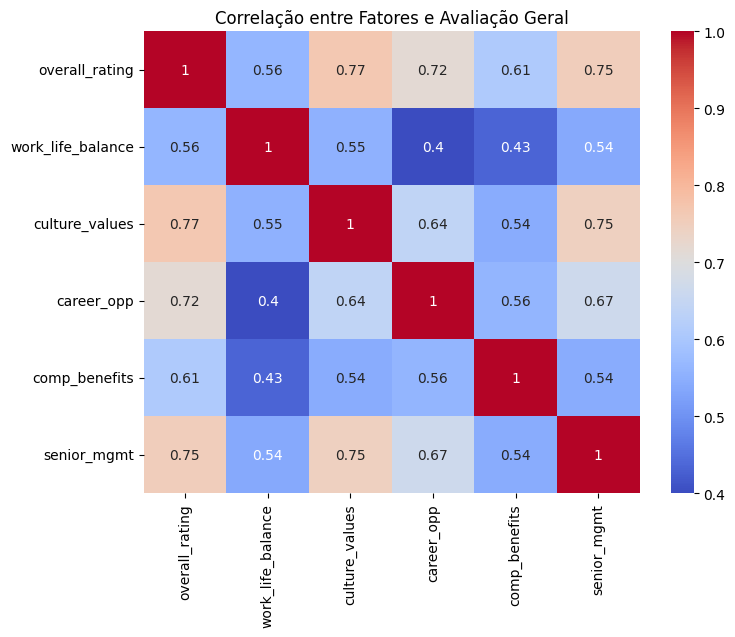

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[[
    'overall_rating',
    'work_life_balance',
    'culture_values',
    'career_opp',
    'comp_benefits',
    'senior_mgmt'
]].corr(), annot=True, cmap='coolwarm')

plt.title('Correlação entre Fatores e Avaliação Geral')
plt.show()

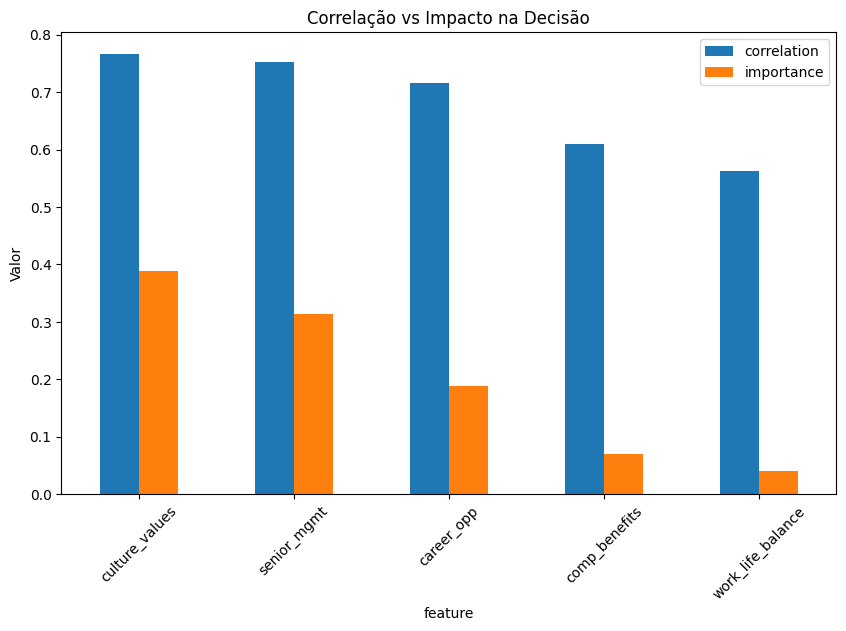

In [ ]:
corr = df[[
    'overall_rating',
    'work_life_balance',
    'culture_values',
    'career_opp',
    'comp_benefits',
    'senior_mgmt'
]].corr()['overall_rating'].drop('overall_rating')

compare_df = pd.DataFrame({
    'feature': corr.index,
    'correlation': corr.values,
    'importance': importance_df.set_index('feature').loc[corr.index]['importance']
})

compare_df = compare_df.sort_values(by='importance', ascending=False)

compare_df.plot(x='feature', kind='bar', figsize=(10,6))
plt.title('Correlação vs Impacto na Decisão')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.show()